# Credit Risk and Scorecard Mangement Project

Hi everyone, today, we are going to start our new Finance project. In this project we'll be working on a common problem for banks, i.e., whether to approve loan for a customer or not, or more specifically, in this project we will be creating a Machine Learning model which classifies whether a customer will default the loan in future or not, using historical data.

For this modelling, we are using the dataset "The Lending Club Dataset" sourced from kaggle, having a shape of (2260701, 151), however, due to system specification constraint and for learning purpose, we'll only consider a random sample of 10 important columns from the data and 2L rows.


This notebook contains the following sections:


1. Business Understanding
2. Data Understanding
3. Data Cleaning
4. Good-Bad Definition
5. EDA (Risk-focused)
6. Binning
7. WOE Transformation
8. IV Calculation
9. Logistic Regression Model
10. Model Evaluation (ROC-AUC, KS)
11. Scorecard Development
12. Risk Segmentation
13. Credit Policy Recommendation


Here, steps 9 and 10 will be repeated multiple times for optimization.


## Prerequisites

This section contains:
1. Import of Librabries to used
2. Loading the Dataset
3. Working Variables
4. Notebook Settings

In [1]:
# Required Libraries


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ML Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, recall_score, classification_report



In [2]:
# Working Variables (Input from User)

# Loss incurred by proving loan to a defaulter who was considered as non-defaulter by our model.
false_neg_cost = 100000

# Loss incurred by rejecting a non-defaulter who was considered as defaulter by our model.
false_pos_cost = 10000

In [3]:
# Changing float view format of entire sheet

pd.set_option("display.float_format", "{:.4f}".format)

In [99]:
# Loading Dataset with to be used columns only.

# This is to be ran only once.

cols = [
    'loan_status', # Loan is paid, charged off, or something else.
    'loan_amnt', # Amount of Loan
    'annual_inc', # The self-reported annual income provided by the borrower
    # during registration
    'dti', # A ratio calculated using the borrower's total monthly debth
    # payments on the total debt obligations, excluding mortgage and the
    # requested LC loan, divided by the borrower's self-reported monthly income.
    'revol_util', # Revolvig line utilization rate, or the amount of credit the
    # borrower is using relative to all available revolving credit.
    'delinq_2yrs', # The number of 30+ past-due incidences of delinquency in the
    # borrower's credit file for the past 2 years.
    'inq_last_6mths', # The nuber of inquiries in past 6 months
    #  (excluding auto and mortgage inquiries)
    'open_acc', # The number of open credit lines in the borrower's credit file.
    'pub_rec', # Number of derogatory public records.
    'grade' # LC assigned loan grade
]


df = pd.read_csv("credit_loan_data.csv", usecols=cols)

In [5]:
df.shape

(2260701, 10)

In [6]:
df = df.sample(n=200000, random_state=42)

In [7]:
df.shape

(200000, 10)

In [8]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             95020
Current                                                77827
Charged Off                                            23788
Late (31-120 days)                                      1985
In Grace Period                                          753
Late (16-30 days)                                        406
Does not meet the credit policy. Status:Fully Paid       153
Does not meet the credit policy. Status:Charged Off       61
Default                                                    3
Name: count, dtype: int64


Here in the data, we know that the "Fully Paid" means no defualt and "Charged Off" means default, with certaininty. All the other values are not known for being default in future or not, so we'll consider only those rows for our work which have either "Fully Paid" or "Charged Off" as loan_status.

In [9]:
# Removed unrequrired rows

df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

In [10]:
df['default_flag'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

In [11]:
df.shape

(118808, 11)

In [12]:
# Checking %Share of Defaults in data
df['default_flag'].value_counts(normalize=True)

,proportion
default_flag,
0,0.7998
1,0.2002


In [13]:
# Removing loan_status columns, as it is no longer required now.

df = df.drop(columns=['loan_status'])

Here, we can see that our data has 79.97% of Good Records and 20.02% of Default records.

We might consider this as imbalanced data, however, in banking sector, this is the type of data we generally use, so we'll keep it natural, i.e., no need to handle the imbalance of dataset.


##1. Business Understanding



1.    Business Objective : Develop a Probability of Default (PD) model using LendingClub loan data to:
      * Predict likelihood of borrower default
      * Support credit approval decisions
      * Enable risk-based segmentation
2.   Business Problem : Incorrect loan approvals lead to either direct loss or opportunity loss.
      * Higher default rates.
      * Financial losses.
      * Portfolio deterioration
      * The goal is to quantify borrower risk before loan approval.

3.    Target Definition:
      * Target variable: default_flag [0, 1]
      * 1 -> Charged Off (Bad)
      * 2 -> Fully Paid (Good)
      * Only Closed loans are used for modelling.

4.    Success Criteria: We aim for
      * ROC-AUC > 0.7
      * Clear KS Separation
      * Logical risk ordering across variables
      * Interpretable coefficients


#2. Data Understanding

In this section, we will understand data:


*   Inspect structure
*   Identify variable types
*   Check missingness
*   Inspect distributions of variables



In [14]:
# Structure

print(df.shape)

(118808, 10)


Data has 1,18,808 rows and 10 columns (9 input features + 1 target variable)

In [15]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 118808 entries, 1273506 to 1005720
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   loan_amnt       118808 non-null  float64
 1   grade           118808 non-null  object 
 2   annual_inc      118808 non-null  float64
 3   dti             118776 non-null  float64
 4   delinq_2yrs     118808 non-null  float64
 5   inq_last_6mths  118808 non-null  float64
 6   open_acc        118808 non-null  float64
 7   pub_rec         118808 non-null  float64
 8   revol_util      118739 non-null  float64
 9   default_flag    118808 non-null  int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 10.0+ MB
None


In [16]:
print(df.head())

         loan_amnt grade  annual_inc     dti  delinq_2yrs  inq_last_6mths  \
1273506  9600.0000     C  21900.0000 10.0300       0.0000          1.0000   
324024   4000.0000     A  83000.0000 19.5300       0.0000          0.0000   
2066630  6025.0000     B  52000.0000  9.1600       1.0000          1.0000   
1975547 20000.0000     B 100000.0000 16.4300       1.0000          0.0000   
302723   1000.0000     B  23000.0000 16.3400       1.0000          0.0000   

         open_acc  pub_rec  revol_util  default_flag  
1273506   13.0000   1.0000     38.9000             0  
324024    16.0000   0.0000     17.2000             0  
2066630   11.0000   0.0000     12.8000             0  
1975547   15.0000   0.0000     56.3000             0  
302723     6.0000   0.0000     77.1000             0  


Here we can see, dataset has 9 numerical columns (including target variable) and 1 categorical column.

Also, our dataset contains some missing values as well.

In [17]:
# Separated Categorical and Numerical Columns
col_cat = list(df.select_dtypes(include=['object']).columns)
col_num = list(df.select_dtypes(include=['float64', 'int64']).columns)
print(col_cat, col_num)

['grade'] ['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'default_flag']


In [18]:
# Checking dataset numberical properties

print(df.describe())

        loan_amnt    annual_inc         dti  delinq_2yrs  inq_last_6mths  \
count 118808.0000   118808.0000 118776.0000  118808.0000     118808.0000   
mean   14401.9818    76098.4251     18.3173       0.3184          0.6593   
std     8714.2406    71004.6356     11.3242       0.8705          0.9398   
min      500.0000        0.0000      0.0000       0.0000          0.0000   
25%     7925.0000    46000.0000     11.7900       0.0000          0.0000   
50%    12000.0000    65000.0000     17.6800       0.0000          0.0000   
75%    20000.0000    90000.0000     24.1000       0.0000          1.0000   
max    40000.0000 10999200.0000    999.0000      29.0000          7.0000   

         open_acc     pub_rec  revol_util  default_flag  
count 118808.0000 118808.0000 118739.0000   118808.0000  
mean      11.5936      0.2155     51.8941        0.2002  
std        5.4525      0.6218     24.5530        0.4002  
min        1.0000      0.0000      0.0000        0.0000  
25%        8.0000      0.

Following are the observations:

<table>
  <thead>
    <td><b>Variable</b></td>
    <td><b>Issue</b></td>
    <td><b>Action</b></td>
  </thead>
  <tr>
    <td>annual_inc</td>
    <td>min=0 and max=109,99,9200</td>
    <td>Outlier Treatment</td>
  </tr>
  <tr>
    <td>dti</td>
    <td>Max 999</td>
    <td>Cap or Clean</td>
  </tr>
  <tr>
    <td>revol_util</td>
    <td>Extreme Max 146.1</td>
    <td>Cap </td>
  </tr>
  <tr>
    <td>pub_rec</td>
    <td>Extreme Max 61</td>
    <td>Binning</td>
  </tr>
</table>


In [19]:
# Checking missing values:

print(df.isnull().mean().sort_values(ascending=False))

revol_util       0.0006
dti              0.0003
grade            0.0000
loan_amnt        0.0000
delinq_2yrs      0.0000
annual_inc       0.0000
inq_last_6mths   0.0000
open_acc         0.0000
pub_rec          0.0000
default_flag     0.0000
dtype: float64


Missing Values found in the dataset in the following columns:


*   dti : 32 (0.03%, Minor)
*   revol_util : 69 (0.06%, Minor)



In [20]:
# Target Distribution:
print(df['default_flag'].value_counts(normalize=True))

default_flag
0   0.7998
1   0.2002
Name: proportion, dtype: float64


The target variable has approx 80:20 ratio of Good and Bad respectively.

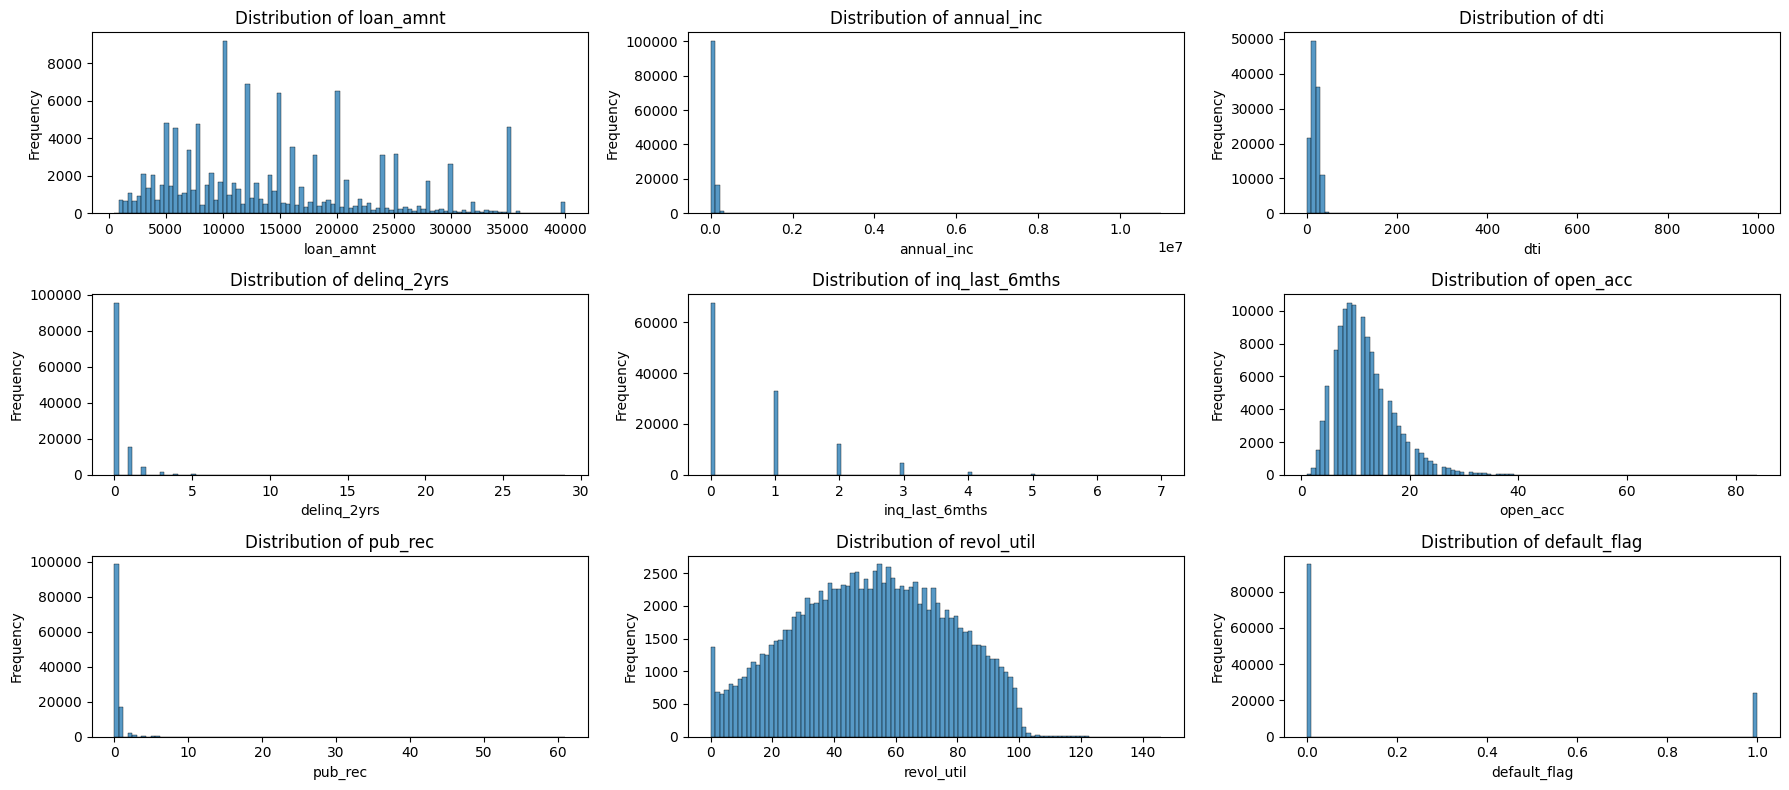

In [21]:
# Plotting Histograms for each columns

fig, axes = plt.subplots(3, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(col_num):
  sns.histplot(df[col], bins=100, ax=axes[i])
  axes[i].set_title(f'Distribution of {col}')
  axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

From these distributions, we having following observations:

* Distribution of loan_amnt is seeming to be discretized (may be due to Leading Club loan slabs), but is with a mild right skewness.
* Annual income is showing values heavily near 0.0, can say extremely right skewed, can have potential outlier, which is distorting the actual distribution.
* dti is also heavily right skewed, also, can have potential outlier (as we have already seen the unimaginary max value of 999).
* deliq_2yrs, inq_last_6mths, pub_rec are showing similar properties as above.
* open_acc is also having a good amount of skewness.
* revol_util is something interesting, it have many values near 0 (can say a ceiling or floor effect) means, many borrowers uses near to 0% or their available credit limit, then the curve ahead suddenly turns to normal with mild right skweness.

# Data Cleaning

This is the section where we:


1. Handle 999 DTI
2. Cap Extreme Income
3. Cap revol_util > 100
4. Treat Zero income
5. Handle Missing Values


### Handling Problems other than Missing values.

For doing this we have three approaches:
1. Percentile Clipping (0.99 percentile, +Statistical Method, -No Domain Knowledge)
2. Rule-Based Cleaning (+Domain Specific, +Remove or clip rows with do not follow certain rules, -but can remove excess data).
3. Hybrid Approach (Apply Rule-Based Cleaning, then Percentile Clipping, +Combination on Domain knowledge and Statistics)

In [22]:
# Rule Based Cleaning

df = df[df['dti']!=999] # Remove rows having dti = 999.
df= df[df['annual_inc']!=0] # Remove rows having annual_inc = 0
df['revol_util'] = df['revol_util'].clip(upper=100) # Replaced revol_util > 100 to = 100.

In [23]:
df.describe()

,loan_amnt,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag
count,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118703.0000,118772.0000
mean,14399.9516,76121.4705,18.2843,0.3184,0.6594,11.5942,0.2155,51.8831,0.2002
std,8712.3133,71003.0540,9.7903,0.8705,0.9398,5.4525,0.6219,24.5273,0.4002
min,500.0000,1000.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
25%,7925.0000,46000.0000,11.7900,0.0000,0.0000,8.0000,0.0000,33.5000,0.0000
50%,12000.0000,65000.0000,17.6800,0.0000,0.0000,11.0000,0.0000,52.3000,0.0000
75%,20000.0000,90000.0000,24.1000,0.0000,1.0000,14.0000,0.0000,70.9000,0.0000
max,40000.0000,10999200.0000,697.0400,29.0000,7.0000,84.0000,61.0000,100.0000,1.0000


In [24]:
# Percentile Capping

dti_upper = df['dti'].quantile(0.99)
print(df[df['dti']>dti_upper].shape)
df['dti'] = df['dti'].clip(upper=dti_upper) # Clipped dti on 99th percentile (1178 Records Updated)

(1178, 10)


In [25]:
inc_upper = df['annual_inc'].quantile(0.99)
print(df[df['annual_inc']>inc_upper].shape)
df['annual_inc'] = df['annual_inc'].clip(upper=inc_upper) # Clipped annual_inc on 99th percentile (1156 Records Updated)

(1156, 10)


In [26]:
df.describe()

,loan_amnt,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag
count,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118772.0000,118703.0000,118772.0000
mean,14399.9516,74499.3861,18.1594,0.3184,0.6594,11.5942,0.2155,51.8831,0.2002
std,8712.3133,42030.3312,8.4441,0.8705,0.9398,5.4525,0.6219,24.5273,0.4002
min,500.0000,1000.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
25%,7925.0000,46000.0000,11.7900,0.0000,0.0000,8.0000,0.0000,33.5000,0.0000
50%,12000.0000,65000.0000,17.6800,0.0000,0.0000,11.0000,0.0000,52.3000,0.0000
75%,20000.0000,90000.0000,24.1000,0.0000,1.0000,14.0000,0.0000,70.9000,0.0000
max,40000.0000,250000.0000,38.4000,29.0000,7.0000,84.0000,61.0000,100.0000,1.0000


After doing data cleaning (other than Missing values) our dataset has 1,18,772 records.

### Handling Missing Values

In [27]:
print(df.isnull().sum().sort_values(ascending=False)) # Missing Values found only in one column revol_util (69 records)

revol_util        69
loan_amnt          0
grade              0
annual_inc         0
delinq_2yrs        0
dti                0
inq_last_6mths     0
open_acc           0
pub_rec            0
default_flag       0
dtype: int64


In [28]:
print(df.isnull().mean().sort_values(ascending=False)) # % Missing values in revol_util col is very low 0.06% (Safe to remove)

revol_util       0.0006
loan_amnt        0.0000
grade            0.0000
annual_inc       0.0000
delinq_2yrs      0.0000
dti              0.0000
inq_last_6mths   0.0000
open_acc         0.0000
pub_rec          0.0000
default_flag     0.0000
dtype: float64


In [29]:
# Removing Rows having null values in revol_util column

df = df.dropna(subset=['revol_util'])

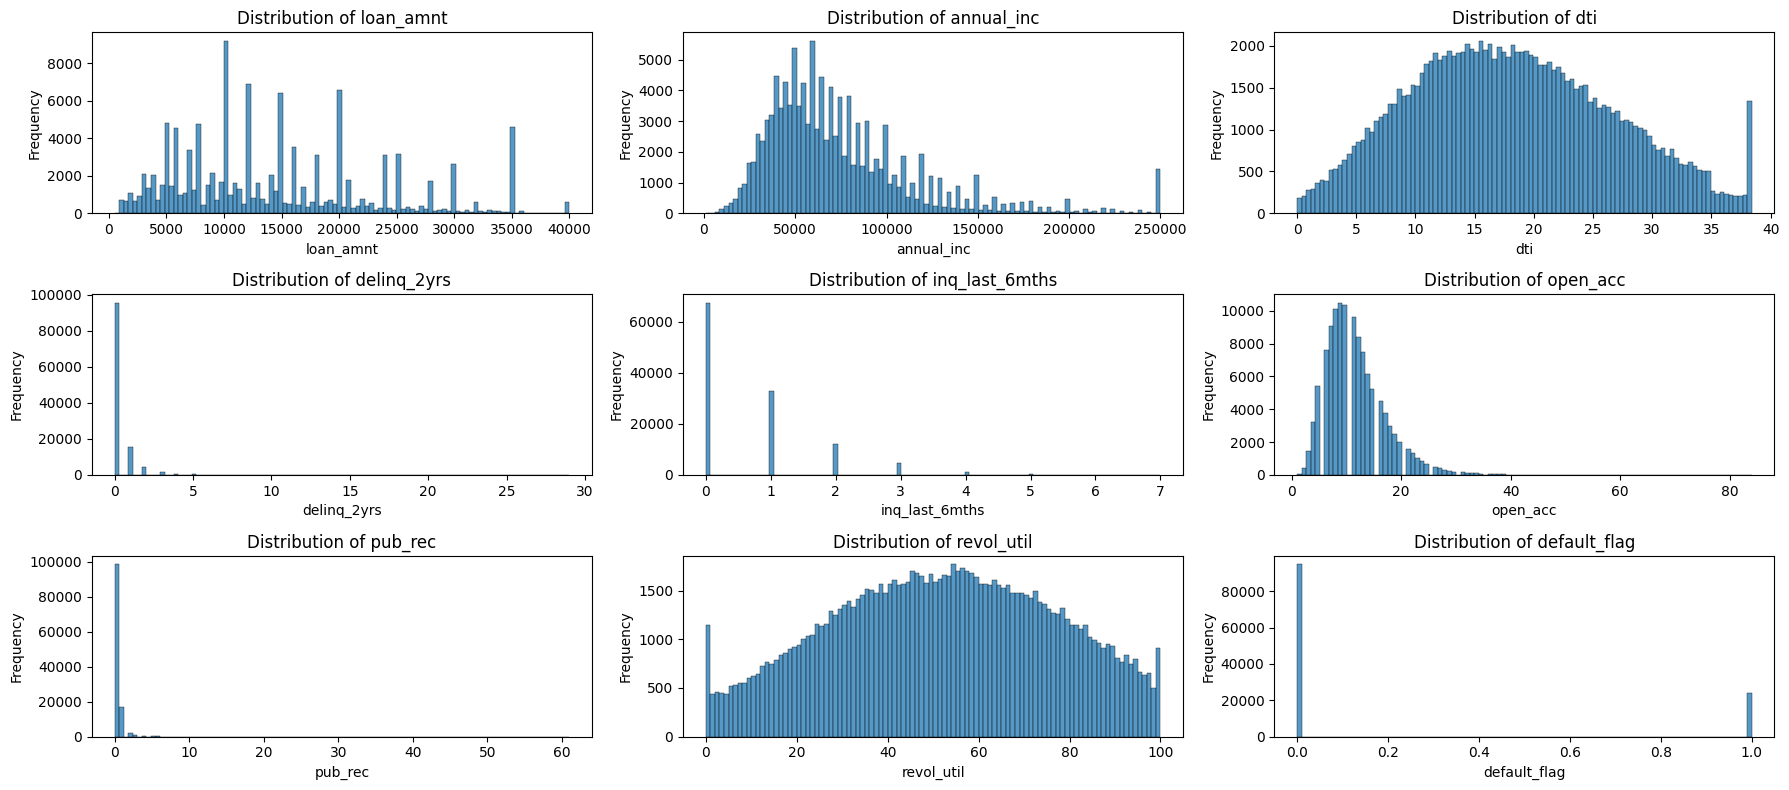

In [30]:
# Plotting Histograms for each column again after Data Cleaning

fig, axes = plt.subplots(3, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(col_num):
  sns.histplot(df[col], bins=100, ax=axes[i])
  axes[i].set_title(f'Distribution of {col}')
  axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [31]:
# Checking Final description of our dataset

print(df.describe())

        loan_amnt  annual_inc         dti  delinq_2yrs  inq_last_6mths  \
count 118703.0000 118703.0000 118703.0000  118703.0000     118703.0000   
mean   14401.4340  74488.3086     18.1620       0.3181          0.6595   
std     8712.0259  42015.9277      8.4427       0.8698          0.9398   
min      500.0000   1000.0000      0.0000       0.0000          0.0000   
25%     7925.0000  46000.0000     11.7900       0.0000          0.0000   
50%    12000.0000  65000.0000     17.6800       0.0000          0.0000   
75%    20000.0000  90000.0000     24.1000       0.0000          1.0000   
max    40000.0000 250000.0000     38.4000      29.0000          7.0000   

         open_acc     pub_rec  revol_util  default_flag  
count 118703.0000 118703.0000 118703.0000   118703.0000  
mean      11.5983      0.2156     51.8831        0.2002  
std        5.4509      0.6220     24.5273        0.4002  
min        1.0000      0.0000      0.0000        0.0000  
25%        8.0000      0.0000     33.5000  

### Data cleaning Successfully completed

Following notes:

1. Removed unrealitic DTI 999.
2. Removed annual_inc = 0 cases.
3. Capped rev_util to 100%.
4. After removing DTI 999, capped dti with 99 percentile.
5. After removing annual_inc = 0 cases, capped annual_inc with 99 percentile.
6. Count Variables left untouched for natural distribution.
7. Final Development dataset has 1,18,703 rows and 9 columns



##4. Good and Bad Definition

In [32]:
# Checking Distribution of target varible (Bad Rate)
print(df['default_flag'].value_counts())
print()
print(df['default_flag'].value_counts(normalize=True))

default_flag
0    94935
1    23768
Name: count, dtype: int64

default_flag
0   0.7998
1   0.2002
Name: proportion, dtype: float64


Our data is showing that:

*   It has 94935 (79.98% ~ 80%) Good (Non Default) records
*   It has 23768 (20.02% ~ 20%) Bad (Default) records

So, Bad Rate : 20% (0.2)

Hence, we can say, we are working on Mid-risk unsecured loan segment.


Note: Low Risk segment (Prime) : Bad rate <= 5%, High Risk Segment (Sub-Prime) : Bad rate > 30%.


##5. Risk-Focused EDA (Exploratory Data Analysis)

In this section, we find try to observe the pattern(s) (if any) of change in risk with respect to different input features.



Risk Based on Financial Features
1. Risk by Grade
2. Risk by DTI Bands
3. Risk by Income Bands
4. Risk by Revolving Utilization

Risk Based on Count Features

5. Risk by delinq_2yrs
6. inq_last_6mths
7. pub_rec
8. open_acc


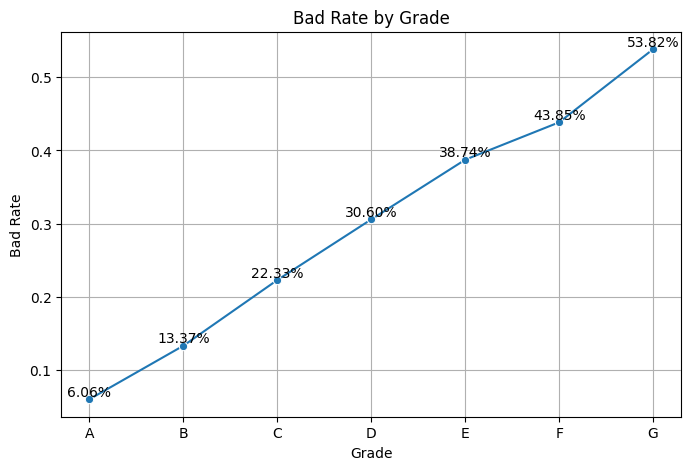

In [33]:
# Risk by Grade
data_temp = df.groupby('grade')['default_flag'].mean().sort_index()

plt.figure(figsize=(8, 5))

ax = sns.lineplot(
    x=data_temp.index,
    y=data_temp.values,
    marker='o'
)

for x, y in zip(data_temp.index, data_temp.values):
    ax.text(x, y, f"{y:.2%}",
            ha='center',
            va='bottom')

plt.xlabel("Grade")
plt.ylabel("Bad Rate")
plt.title("Bad Rate by Grade")
plt.grid(True)

plt.show()

This shows a clear monotonic increase in Bad Rate with Degradation of Grade.
i.e.,


*   A -> 6.06% (Very Safe Segment, least bad rate)
*   G -> 53.82% (Highly Risky Segment, max bad rate)

This also suggests us that this is a strong variable. However, this varible is an outcome of internal modelling of 'Lending Clud' and will not be there in real scenarios. <br>
So, here for learning purposes, we are considering this variable.


In [34]:
# Risk By DTI Bands

# Create DTI Bands
df['dti_band'] = pd.cut(df['dti'], bins=5)
data_temp = df.groupby('dti_band')['default_flag'].agg(['count', 'mean'])
print(data_temp)



                 count   mean
dti_band                     
(-0.0384, 7.68]  13068 0.1446
(7.68, 15.36]    34458 0.1598
(15.36, 23.04]   37314 0.2015
(23.04, 30.72]   23931 0.2474
(30.72, 38.4]     9932 0.2953


/tmp/ipykernel_754/2021144777.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_temp = df.groupby('dti_band')['default_flag'].agg(['count', 'mean'])


Here, we can see, that while proceeding to the higher dti bands, bad_rate increases monotonically.

* Lowest DTI Band : (-0.0384, 7.68] : Bad Rate - 14.46% : Min
* Highest DTI Band : [30.72, 38.4] : Bad Rate - 29.53% : Max

This monotonic increment nature suggests that, dti is a strong input variable.


In [35]:
# Risk By Income Bands

df['income_band'] = pd.cut(df['annual_inc'], bins=5)

print(df.groupby('income_band')['default_flag'].agg(['count', 'mean']))

                      count   mean
income_band                       
(751.0, 50800.0]      38517 0.2292
(50800.0, 100600.0]   58325 0.1963
(100600.0, 150400.0]  15706 0.1625
(150400.0, 200200.0]   3686 0.1555
(200200.0, 250000.0]   2469 0.1482


/tmp/ipykernel_754/3745616944.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('income_band')['default_flag'].agg(['count', 'mean']))


We can observe that, low income suggests higher bad rate, or we can say, increasing the income suggests decrease in bad rate, which is intuitively acceptable.

* Lowest Income Band : (751, 50800] : Bad Rate - 22.92% : Max
* Highest Income Band : (200200, 250000] : Bad Rate - 14.82% : Min

Also, here we can see the monotonic decrement in bad rate while increasing the income.

Hence, annual_income is also a strong input feature.

In [36]:
# Risk By Revolving Utilization

df['util_band'] = pd.cut(df['revol_util'], bins=5)

print(df.groupby('util_band')['default_flag'].agg(['count', 'mean']))

               count   mean
util_band                  
(-0.1, 20.0]   13599 0.1493
(20.0, 40.0]   25893 0.1814
(40.0, 60.0]   32950 0.2049
(60.0, 80.0]   28850 0.2197
(80.0, 100.0]  17411 0.2269


/tmp/ipykernel_754/1640257116.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('util_band')['default_flag'].agg(['count', 'mean']))


With this, we can clearly observe, lower credit utilization decreases the bad rate.

* Lower Util Band : (-0.1, 20] : Bad Rate - 14.93% : Min
* Highest Util Band : (80, 100] : Bad Rate - 22.69% : Max

This suggests, that there is a monotonically increasing relationship exists between 'revol_util' and bad rate.

This means, revol_util is a strong feature for modelling.

In [37]:
# Risk By delin_2yrs


df.groupby('delinq_2yrs')['default_flag'].agg(['count', 'mean'])

,count,mean
delinq_2yrs,,
0.0000,95608,0.1968
1.0000,15481,0.2091
2.0000,4442,0.2199
3.0000,1580,0.2449
4.0000,699,0.2146
5.0000,373,0.2306
6.0000,213,0.2394
7.0000,126,0.2143
8.0000,67,0.2090


Here, we can observe that the number of observations in delinq_2yrs = 0, 1, 2 are significant in numbers (can also consider value 3) but after that the number of observations are very less in number to tell about the true nature of the bad rate.

Since, upto delinq 3, there is a monotonic increase in bad rate, but after that rate breaks the monotonic property.

So, for proper study of bad rate in this, we need to manually bin the delinq_2yrs.

In [38]:
# Inspection of Risk by Manual Binning of delinq_2yrs column


print("delinq_2yrs")
temp_df1 = df[df['delinq_2yrs'].isin([0, 1, 2])].groupby('delinq_2yrs')['default_flag'].agg(['count', 'mean'])

mean_t = round(df[df['delinq_2yrs']>=3]['default_flag'].agg(['count', 'mean'])['mean'], 4)
count_t = df[df['delinq_2yrs']>=3]['default_flag'].agg(['count', 'mean'])['count']

temp_df2 = pd.DataFrame({'count': count_t, 'mean': mean_t}, index=['3+'])

pd.concat([temp_df1, temp_df2])

delinq_2yrs


,count,mean
0.0000,95608.0000,0.1968
1.0000,15481.0000,0.2091
2.0000,4442.0000,0.2199
3+,3172.0000,0.2342


Now, it can be clearly observed that increase in delinquencies suggests increase in bad rate.

In [39]:
# Manual Binning on inq_last_6mths column


print("inq_last_6mths")
temp_df1 = df[df['inq_last_6mths'].isin([0, 1, 2])].groupby('inq_last_6mths')['default_flag'].agg(['count', 'mean'])

mean_t = round(df[df['inq_last_6mths']>=3]['default_flag'].agg(['count', 'mean'])['mean'], 4)
count_t = df[df['inq_last_6mths']>=3]['default_flag'].agg(['count', 'mean'])['count']

temp_df2 = pd.DataFrame({'count': count_t, 'mean': mean_t}, index=['3+'])

pd.concat([temp_df1, temp_df2])


inq_last_6mths


,count,mean
0.0000,67575.0000,0.1806
1.0000,32733.0000,0.2135
2.0000,12058.0000,0.2413
3+,6337.0000,0.2623


We can observe that, this distribution suggests, increase in number of inquiries results in increasing bad rate.



*   inq_last_6mths = 0 : Bad Rate : 18.06% Min
*   inq_last_6mths >= 3 : Bad Rate : 26.23% Max

This means, inq_last_6mths, is a strong feature



In [40]:
# Risk by pub_rec

col = 'pub_rec'

print(col)
temp_df1 = df[df[col].isin([0, 1, 2])].groupby(col)['default_flag'].agg(['count', 'mean'])

mean_t = round(df[df[col]>=3]['default_flag'].agg(['count', 'mean'])['mean'], 4)
count_t = df[df[col]>=3]['default_flag'].agg(['count', 'mean'])['count']

temp_df2 = pd.DataFrame({'count': count_t, 'mean': mean_t}, index=['3+'])

pd.concat([temp_df1, temp_df2])


pub_rec


,count,mean
0.0000,98579.0000,0.1941
1.0000,16841.0000,0.2295
2.0000,2181.0000,0.2412
3+,1102.0000,0.2223


This feature also suggests increase in bad rate (not monotonic) with increase in number of pub_rec.

In [41]:
# Risk by open_acc

col = 'open_acc'

df.groupby(col)['default_flag'].agg(['count', 'mean'])

open_acc


,count,mean
open_acc,,
1.0000,39,0.2821
2.0000,410,0.2146
3.0000,1485,0.1690
4.0000,3249,0.1788
5.0000,5428,0.1805
6.0000,7604,0.1825
7.0000,9036,0.1899
8.0000,10075,0.1894
9.0000,10489,0.1961


In this result, the rows having stable number of records (between 2000 to 11000) are showing monotonic increasing bad rate, however, other rows having less data has usually high bad rate, but not monotonic in nature.

Hence, we can conclude that increase in number of open_acc suggests increase in bad rate.

So, open_acc is also a inflencial feature for this project.

##6. Binning

In this section, we'll do feature engineering. As we are working to create a classical banking scorecard system that uses 'Binning + WOE + IV' approach, so we'll be proceeding with the following steps:
1. Choose one variable at a time.
2. Initial Binning: For continuous -> quantile based, for count -> manual.
3. Get Per-Bin Summary.
4. Check Monotonicity.
5. Merge Bins (if needed).
6. Finalize the Bins.

In [42]:
df.head()

,loan_amnt,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,dti_band,income_band,util_band
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,"(7.68, 15.36]","(751.0, 50800.0]","(20.0, 40.0]"
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,"(15.36, 23.04]","(50800.0, 100600.0]","(-0.1, 20.0]"
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,"(7.68, 15.36]","(50800.0, 100600.0]","(-0.1, 20.0]"
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,"(15.36, 23.04]","(50800.0, 100600.0]","(40.0, 60.0]"
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,"(15.36, 23.04]","(751.0, 50800.0]","(60.0, 80.0]"


Since, the bands created in the previous columns were only for exploratory purpose, so we'll drop them and create new as needed.

In [43]:
# Dropping dti_band, income_band, util_band

df.drop(columns=['dti_band', 'income_band', 'util_band'], errors='ignore', inplace=True)

In [44]:
df.head()

,loan_amnt,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0


### Binning for Continuous variables

* DTI
* Annual Income
* Revolving Utilization



           dti_bin  count   mean
0  (-0.001, 10.55]  23778 0.1490
1   (10.55, 15.36]  23748 0.1622
2   (15.36, 20.04]  23711 0.1930
3   (20.04, 25.75]  23760 0.2266
4    (25.75, 38.4]  23706 0.2705


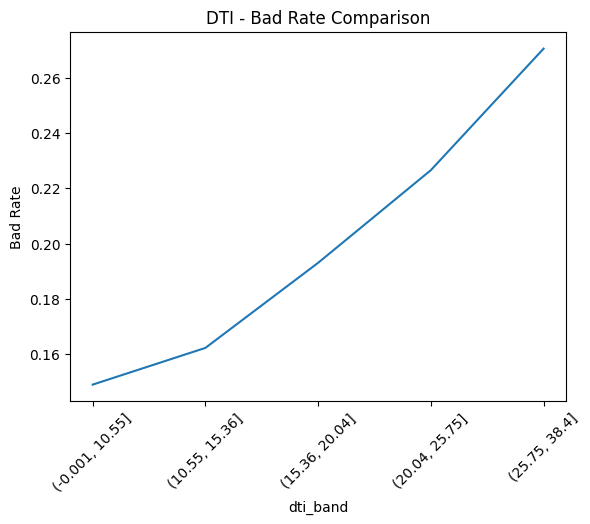

In [45]:
# DTI Binning

col = 'dti'

df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')

dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary['dti_bin'] = dti_summary['dti_bin'].astype(str)

sns.lineplot(x=dti_summary['dti_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel("dti_band")
plt.ylabel("Bad Rate")
plt.title("DTI - Bad Rate Comparison")
plt.show()

We can observe a monotonic increase in bad rate with the increasing bins dti values.
So, we keep this binning.

         annual_inc_bin  count   mean
0    (999.999, 42000.0]  24258 0.2373
1    (42000.0, 57000.0]  23647 0.2158
2    (57000.0, 74000.0]  23537 0.2010
3   (74000.0, 100000.0]  25318 0.1845
4  (100000.0, 250000.0]  21943 0.1597


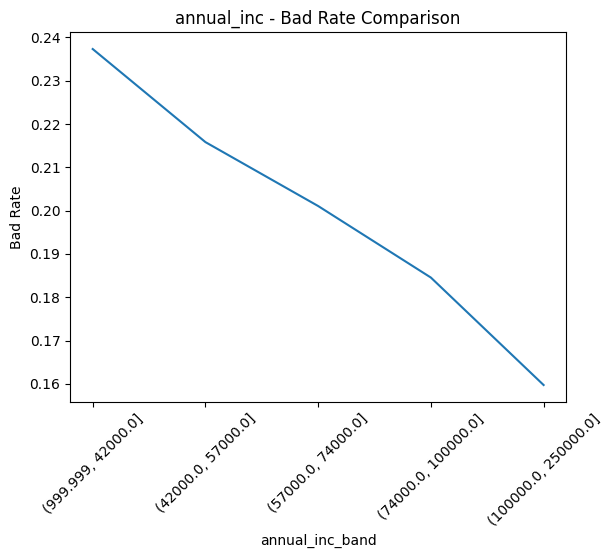

In [46]:
# Annual Income Binning

col = 'annual_inc'

df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')

dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Annual Income also showing downward trend.

   revol_util_bin  count   mean
0  (-0.001, 29.1]  23784 0.1562
1    (29.1, 45.1]  23786 0.1941
2    (45.1, 59.3]  23705 0.2067
3    (59.3, 75.1]  23770 0.2194
4   (75.1, 100.0]  23658 0.2249


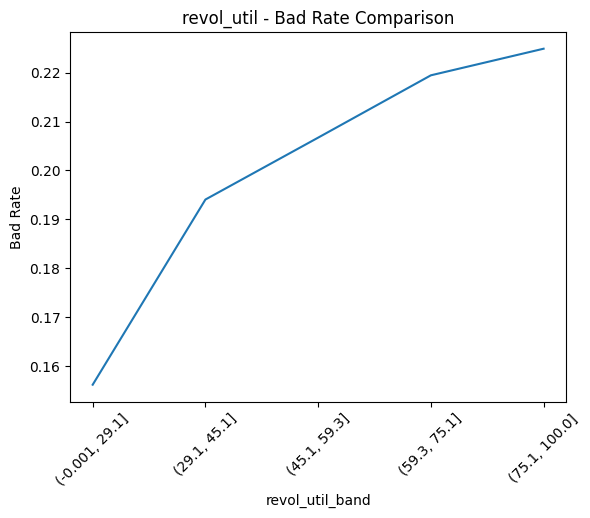

In [47]:
# Revolving Utilization Binning

col = 'revol_util'

df[f'{col}_bin'] = pd.qcut(df[col], q=5, duplicates='drop')

dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Revolving Utilization showing monotonic increment in bad rate with increasing utilization.

### Binning for Count Variables

* delinq_2yrs
* inq_last_6mths
* open_acc
* pub_rec

In [48]:
df.head()

,loan_amnt,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,dti_bin,annual_inc_bin,revol_util_bin
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,"(-0.001, 10.55]","(999.999, 42000.0]","(29.1, 45.1]"
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,"(15.36, 20.04]","(74000.0, 100000.0]","(-0.001, 29.1]"
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,"(-0.001, 10.55]","(42000.0, 57000.0]","(-0.001, 29.1]"
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,"(15.36, 20.04]","(74000.0, 100000.0]","(45.1, 59.3]"
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,"(15.36, 20.04]","(999.999, 42000.0]","(75.1, 100.0]"


  delinq_2yrs_bin  count   mean
0               0  95608 0.1968
1               1  15481 0.2091
2               2   4442 0.2199
3              3+   3172 0.2342


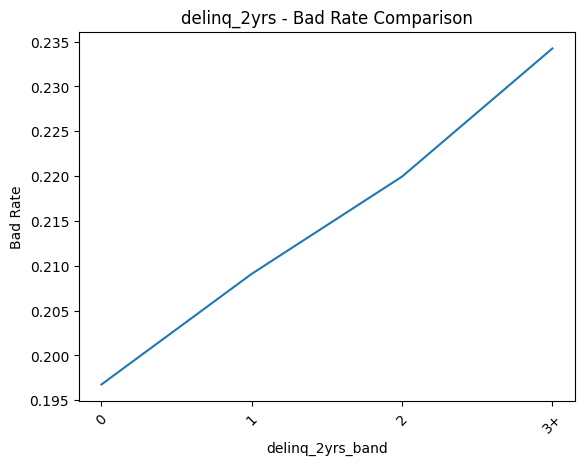

In [49]:
# delinq_2yrs Binning

col = 'delinq_2yrs'

df[f'{col}_bin'] = df[f'{col}'].apply(
    lambda x: '0' if x==0 else
              '1' if x==1 else
              '2' if x==2 else
              '3+'
)



dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Monotonic Increasing Bad Rate with increasing bin values of delinq_2yrs with stable number of columns.

  inq_last_6mths_bin  count   mean
0                  0  67575 0.1806
1                  1  32733 0.2135
2                  2  12058 0.2413
3                  3   4573 0.2556
4                 4+   1764 0.2795


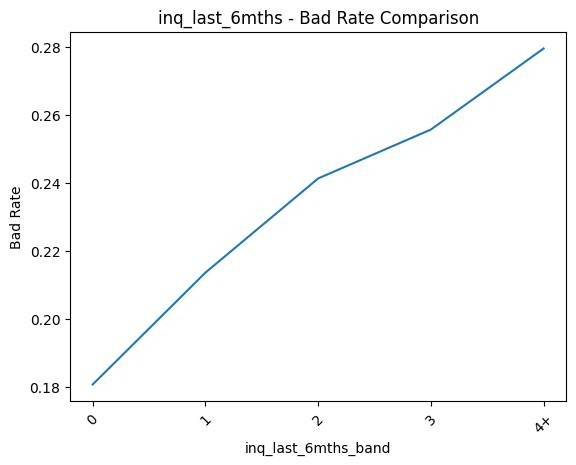

In [50]:
# inq_last_6mths Binning

col = 'inq_last_6mths'

df[f'{col}_bin'] = df[f'{col}'].apply(
    lambda x: '0' if x==0 else
              '1' if x==1 else
              '2' if x==2 else
              '3' if x==3 else
              '4+'
)



dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Created 6 bins for reflecting monotonic nature and stable number of records in each bin.

Inq_last_6mths showing monotonic increasing bad rate.

  open_acc_bin  count   mean
0          1-5  10611 0.1801
4         6-10  47532 0.1928
1        11-15  36847 0.2045
2        16-20  15715 0.2116
3          21+   7998 0.2292


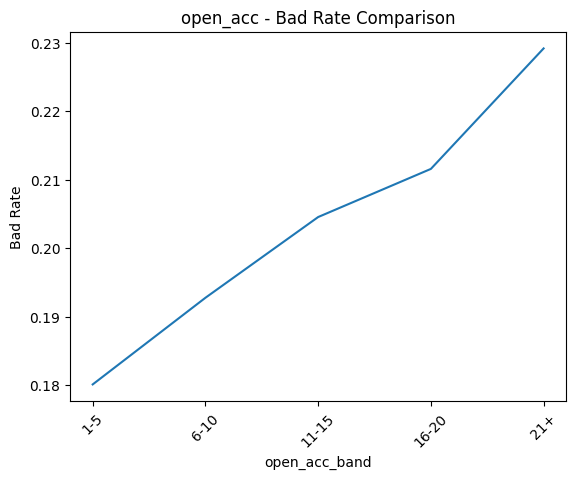

In [51]:
# open_acc Binning

col = 'open_acc'


def bin_open_acc(x):
    if x <= 5:
        return '1-5'
    elif x <= 10:
        return '6-10'
    elif x <= 15:
        return '11-15'
    elif x <= 20:
        return '16-20'
    else:
        return '21+'

df[f'{col}_bin'] = df[col].apply(bin_open_acc)



dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index().sort_values(by='mean')

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Showing monotonic nature and stable number of records. 5 Bins are created for this variable

  pub_rec_bin  count   mean
0           0  98579 0.1941
1           1  16841 0.2295
2          2+   3283 0.2348


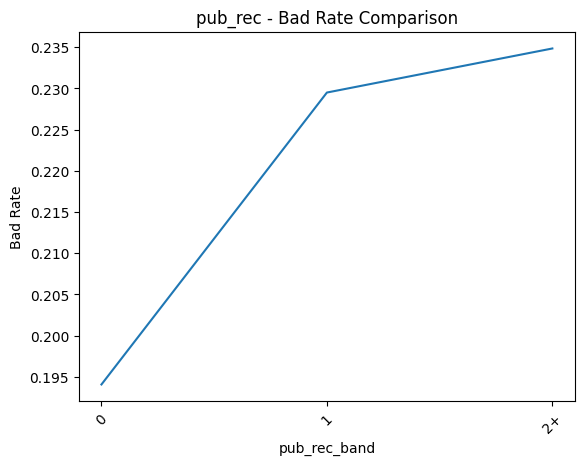

In [52]:
# pub_rec Binning

col = 'pub_rec'

df[f'{col}_bin'] = df[f'{col}'].apply(
    lambda x: '0' if x==0 else
              '1' if x==1 else
              '2+'
)


dti_summary = df.groupby(f'{col}_bin', observed=True)['default_flag'].agg(['count', 'mean']).reset_index()

print(dti_summary)

dti_summary[f'{col}_bin'] = dti_summary[f'{col}_bin'].astype(str)

sns.lineplot(x=dti_summary[f'{col}_bin'], y=dti_summary['mean'])
plt.xticks(rotation=45)
plt.xlabel(f"{col}_band")
plt.ylabel("Bad Rate")
plt.title(f"{col} - Bad Rate Comparison")
plt.show()

Showing increasing trend in bad rate with increasing pub_rec, 3 bins created here.

### Binning Summary



1. dti : 5 Bins Created : Monotonic increase in bad rate
2. annual_inc : 5 Bins Created : Monotonic decrease in bad rate
3. revol_util : 5 Bins Created : Monotonic increase in bad rate
4. delinq_2yrs : 4 Bins Created : Monotonic increase in bad rate
5. inq_last_6mths : 5 Bins Created : Monotonic increase in bad rate
6. open_acc : 5 Bins Created : Monotonic increase in bad rate
7. pub_rec : 3 Bins Created : Monotonic increase in bad rate


##

##7. WOE Transformation

In [53]:
df.head()

,loan_amnt,grade,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,dti_bin,annual_inc_bin,revol_util_bin,delinq_2yrs_bin,inq_last_6mths_bin,open_acc_bin,pub_rec_bin
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,"(-0.001, 10.55]","(999.999, 42000.0]","(29.1, 45.1]",0,1,11-15,1
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,"(15.36, 20.04]","(74000.0, 100000.0]","(-0.001, 29.1]",0,0,16-20,0
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,"(-0.001, 10.55]","(42000.0, 57000.0]","(-0.001, 29.1]",1,1,11-15,0
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,"(15.36, 20.04]","(74000.0, 100000.0]","(45.1, 59.3]",1,0,11-15,0
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,"(15.36, 20.04]","(999.999, 42000.0]","(75.1, 100.0]",1,0,6-10,0


In [54]:
# Creating a function for this WOE Cols
def add_woe(df, col):
  col_woe = col.replace('bin', 'woe')
  woe_table = df.groupby(col, observed=False)['default_flag'].count().reset_index()
  woe_table.rename(columns={'default_flag':'Total'}, inplace=True)

  bins = list(woe_table[col])
  n_good = []
  n_bad = []
  for bin in bins:
    n_good.append(df[(df[col]==bin)&(df['default_flag']==0)].shape[0])
    n_bad.append(df[(df[col]==bin)&(df['default_flag']==1)].shape[0])


  # Create table
  woe_table['good'] = n_good
  woe_table['bad'] = woe_table['Total'] - woe_table['good']
  woe_table['%_good'] = woe_table['good']/woe_table['good'].sum()
  woe_table['%_bad'] = woe_table['bad']/woe_table['bad'].sum()
  woe_table[col_woe] = np.log(woe_table['%_good']/woe_table['%_bad'])

  # Calculating IV
  woe_table['iv_component'] = (woe_table['%_good'] - woe_table['%_bad']) * woe_table[col_woe]
  iv_value = woe_table['iv_component'].sum()




  woe_map = dict(zip(woe_table[col], woe_table[col_woe]))
  updated_df = df.copy()
  updated_df[col_woe] = updated_df[col].map(woe_map)
  return (updated_df, iv_value)


In [55]:
# Executing the function to get WOE Cols and IV Values for each col

woe_cols = ['dti_bin', 'annual_inc_bin', 'revol_util_bin', 'delinq_2yrs_bin', 'inq_last_6mths_bin', 'open_acc_bin', 'pub_rec_bin']
iv_scores = []
temp = df.copy()
# print(temp.head())
for col in woe_cols:
  temp, iv = add_woe(temp, col)
  iv_scores.append(iv)



In [56]:
temp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118703 entries, 1273506 to 1005720
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   loan_amnt           118703 non-null  float64 
 1   grade               118703 non-null  object  
 2   annual_inc          118703 non-null  float64 
 3   dti                 118703 non-null  float64 
 4   delinq_2yrs         118703 non-null  float64 
 5   inq_last_6mths      118703 non-null  float64 
 6   open_acc            118703 non-null  float64 
 7   pub_rec             118703 non-null  float64 
 8   revol_util          118703 non-null  float64 
 9   default_flag        118703 non-null  int64   
 10  dti_bin             118703 non-null  category
 11  annual_inc_bin      118703 non-null  category
 12  revol_util_bin      118703 non-null  category
 13  delinq_2yrs_bin     118703 non-null  object  
 14  inq_last_6mths_bin  118703 non-null  object  
 15  open_acc_bin   

##8. IV Calculation and Analysis

In [57]:
iv_scores_df = pd.DataFrame({'Column': woe_cols, "IV_Score": iv_scores})


In [58]:
iv_scores_df.sort_values(by='IV_Score', ascending=False)

,Column,IV_Score
0,dti_bin,0.0752
1,annual_inc_bin,0.0271
2,revol_util_bin,0.0245
4,inq_last_6mths_bin,0.0244
6,pub_rec_bin,0.0070
5,open_acc_bin,0.0053
3,delinq_2yrs_bin,0.0025


In the Information Scores, we have the following observations:
1. Moderate to Weak Power Predictors (iv > 0.02):
    * dti_bin
    * annual_inc_bin
    * revol_util_bin
    * inq_last_6mths_bin
2. Boderline (iv > 0.005) (Very Weak):
    * pub_rec_bin
    * open_acc_bin
3. Ignorant Predictors (iv < 0.005)
    * delinq_2yrs_bin


This states that, no individual columns is much powerful to be a strong predictor. But the columns can have a strong combined effect.

Also, delinq_2yrs_bin, can't be dropped directly, but can be experimented for model analysis.

In [59]:
# Dataset with woe variables and target variable
df_woe = temp[['dti_woe', 'annual_inc_woe', 'revol_util_woe', 'delinq_2yrs_woe', 'inq_last_6mths_woe', 'open_acc_woe', 'pub_rec_woe', 'default_flag']]

In [60]:
df_woe.head()

,dti_woe,annual_inc_woe,revol_util_woe,delinq_2yrs_woe,inq_last_6mths_woe,open_acc_woe,pub_rec_woe,default_flag
1273506,0.3579,-0.2172,0.0390,0.0219,-0.0812,-0.0267,-0.1737,0
324024,0.0456,0.1011,0.3016,0.0219,0.1271,-0.0694,0.0389,0
2066630,0.3579,-0.0945,0.3016,-0.0545,-0.0812,-0.0267,0.0389,0
1975547,0.0456,0.1011,-0.0400,-0.0545,0.1271,-0.0267,0.0389,0
302723,0.0456,-0.2172,-0.1474,-0.0545,0.1271,0.0474,0.0389,0


##9. Model Creation

In this section we'll be training our logistic regression model, along with evaluation of metrics.

Initially, will train the model with all of the columns, then perform feature selection and other techniques to experiment with the model metrics.

In [61]:
# Baseline Logistic Model with all columns

features = [
    'dti_woe',
    'annual_inc_woe',
    'revol_util_woe',
    'delinq_2yrs_woe',
    'inq_last_6mths_woe',
    'open_acc_woe',
    'pub_rec_woe'
]

X = df_woe[features]
y = df_woe['default_flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_pred, y_test)
recall = recall_score(y_pred, y_test)
cross = np.mean(cross_val_score(LogisticRegression(), X, y, cv=5, scoring='recall'))

print("Accuracy : ", acc)
print("Recall : ", recall)
print("Cross Val Recall : ", cross)

coef_df = pd.DataFrame({
    "Feature" : features,
    "Coeffient" : model.coef_[0]
})



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy :  0.8025329252197355
Recall :  0.0
Cross Val Recall :  0.0


In [62]:
coef_df

,Feature,Coeffient
0,dti_woe,-0.7627
1,annual_inc_woe,-0.9713
2,revol_util_woe,-1.0132
3,delinq_2yrs_woe,-1.3000
4,inq_last_6mths_woe,-1.0720
5,open_acc_woe,-0.7117
6,pub_rec_woe,-1.0383


In [63]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)
print("AUC", auc)

AUC 0.6050689990076407


In [64]:
# Calculating KS Statistic for this
y_pred_proba = model.predict_proba(X_test)[:, 1]
ks_df = pd.DataFrame({
    'y_actual': y_test,
    'y_prob':y_pred_proba
})
ks_df = ks_df.sort_values(by='y_prob')

ks_df['good'] = (ks_df['y_actual']==0).astype(int)
ks_df['bad'] = (ks_df['y_actual']==1).astype(int)

ks_df['cum_good'] = ks_df['good'].cumsum() / ks_df['good'].sum()
ks_df['cum_bad'] = ks_df['bad'].cumsum() / ks_df['bad'].sum()

ks_df['cum_diff'] = abs(ks_df['cum_good'] - ks_df['cum_bad'])
ks_value = ks_df['cum_diff'].max()
print("KS Value : ", ks_value)
print("Occured At : ", ks_df.loc[ks_df['cum_diff'].idxmax()])

KS Value :  0.15171743068860355
Occured At :  y_actual   0.0000
y_prob     0.1894
good       1.0000
bad        0.0000
cum_good   0.5000
cum_bad    0.3483
cum_diff   0.1517
Name: 379868, dtype: float64


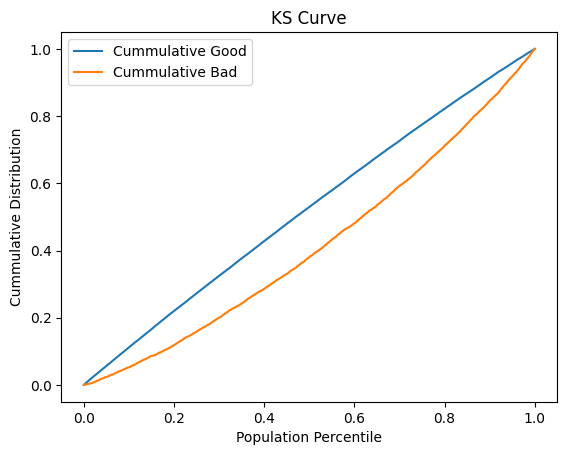

In [65]:
# Plot KS
ks_df['percentile'] = np.arange(len(ks_df)) / len(ks_df)



plt.plot(ks_df['percentile'], ks_df['cum_good'], label='Cummulative Good')
plt.plot(ks_df['percentile'], ks_df['cum_bad'], label='Cummulative Bad')

plt.xlabel("Population Percentile")
plt.ylabel("Cummulative Distribution")
plt.legend()
plt.title("KS Curve")
plt.show()



Confusion Matrix Format

[[TN FP][FN TP]]

<br>
Here, False Negatives are more costly, we'll have good weight of focus on Recall.

Recall Formula : TP / (TP + FN) : Out of Actual Positives, how many our model detected.  

In [66]:
# Confusion Matrix

threshold = 0.5

y_pred_05 = (y_pred_proba >= threshold).astype(int)

cm_05 = confusion_matrix(y_test, y_pred_05)
recall_05 = recall_score(y_test, y_pred_05)

print("Confusion Matrix : ", cm_05)
print()
print("Recall : ", recall_05)

Confusion Matrix :  [[28579     0]
 [ 7032     0]]

Recall :  0.0


In [67]:
# Confusion Matrix

threshold = 0.2

y_pred_02 = (y_pred_proba >= threshold).astype(int)

cm_02 = confusion_matrix(y_test, y_pred_02)
recall_02 = recall_score(y_test, y_pred_02)

print("Confusion Matrix : ", cm_02)
print()
print("Recall : ", recall_02)

Confusion Matrix :  [[16046 12533]
 [ 2891  4141]]

Recall :  0.5888794084186576


In [68]:
threshold = 0.1

y_pred_threshold = (y_pred_proba >= threshold).astype(int)

cm_threshold = confusion_matrix(y_test, y_pred_threshold)
recall_threshold = recall_score(y_test, y_pred_threshold)

print("Confusion Matrix : ", cm_threshold)
print()
print("Recall : ", recall_threshold)

Confusion Matrix :  [[  679 27900]
 [   48  6984]]

Recall :  0.9931740614334471


We can observe that, decrease in threshold results in increasing Recall metric i.e., decreasing False Negatives but also increasing False Positives.

This means we can study for the optimal recall level with minimum False Negative and False Positive by plotting line graphs on Type 2 Error : "False Negative", Type 1 Error : "False Positive" with respect to decreasing threshold.

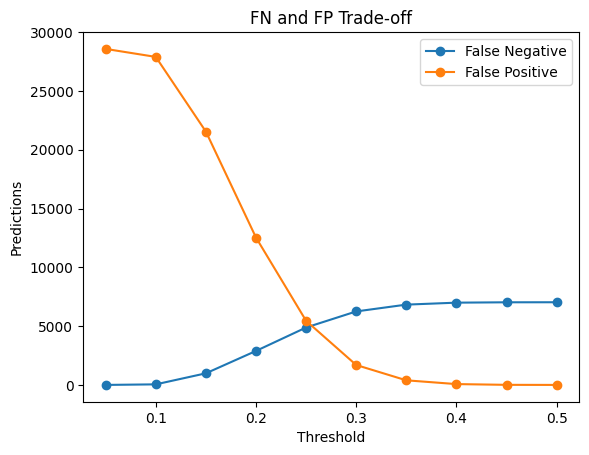

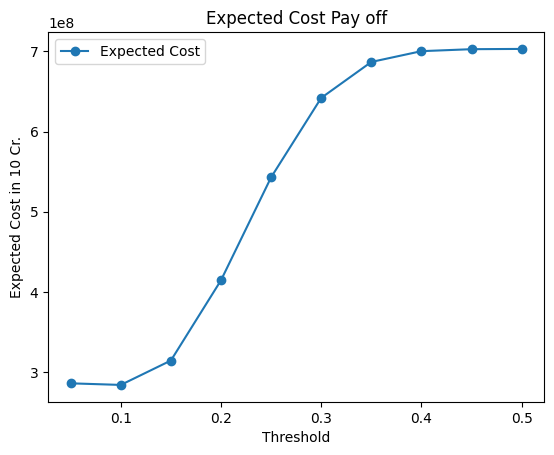

In [69]:
# Creating an dictionary having threshold, False Negative and False Positive.

score_dict = {
    'threshold' : np.arange(0.5, 0, -0.05),
    'false_positive' : [],
    'false_negative' : [],
    'recall' : [],
    'expected_cost' : []
}

for threshold in score_dict['threshold']:
  y_pred_threshold = (y_pred_proba >= threshold).astype(int)
  cm_threshold = confusion_matrix(y_test, y_pred_threshold)
  recall_threshold = recall_score(y_test, y_pred_threshold)

  score_dict['false_positive'].append(cm_threshold[0][1])
  score_dict['false_negative'].append(cm_threshold[1][0])
  score_dict['recall'].append(recall_threshold)



for i in range(len(score_dict['threshold'])):
  score_dict['expected_cost'].append(false_neg_cost * score_dict['false_negative'][i] + false_pos_cost * score_dict['false_positive'][i])



plt.plot(score_dict['threshold'], score_dict['false_negative'], label='False Negative', marker='o')
plt.plot(score_dict['threshold'], score_dict['false_positive'], label='False Positive', marker='o')
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Predictions")
plt.title("FN and FP Trade-off")
plt.show()

# plt.figure(figsize=(8,8))
plt.plot(score_dict['threshold'], score_dict['expected_cost'], label='Expected Cost', marker='o')
# for x, y in zip(score_dict['threshold'], score_dict['expected_cost']):
#   plt.annotate(f"({x:.2f}, {(y/100000000):.2f})", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=8, rotation=45)
plt.legend()
plt.xlabel("Threshold")
plt.ylabel("Expected Cost in 10 Cr.")
plt.title("Expected Cost Pay off")
plt.show()

For now, we can observe that with the existing model and Cost FN 100000 and FP 10000. We have 0.2 threshold that balances minimum expected cost, FP and FN.

Now, will proceed with Model improvement.

In [70]:
# Defining function that performs the following tasks

# 1) Take dataframe, input features and target variable to train Logistic Model
# 3) Computes ROC-AUC Scores
# 4) Computes KS Statistic and Provide KS data with Graph
# 5) Gives Confusion Matrix and Recall Score
# 6) FN and FP Trade off Graph
# 7) Expected Cost Pay off Graph



def create_model(df, features, target):

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)


    coef_df = pd.DataFrame({
        "Feature" : features,
        "Coefficient" : model.coef_[0]
    })
    print("COEFFICIENT VALUES")
    print("================================")
    print(coef_df)

    print("\n\n")


    print("MODEL ACCURACY")
    print("================================")
    print("Accuracy Score : ", accuracy_score(y_pred, y_test))

    print("\n\n")


    print("ROC-AUC SCORE")
    print("================================")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    print("AUC : ", auc)


    print("\n\n")


    print("Kolmogorov-Smirnov Statistic (KS)")
    print("==================================")
    ks_df = pd.DataFrame({
        'y_actual': y_test,
        'y_prob':y_pred_proba
    })
    ks_df = ks_df.sort_values(by='y_prob')

    ks_df['good'] = (ks_df['y_actual']==0).astype(int)
    ks_df['bad'] = (ks_df['y_actual']==1).astype(int)

    ks_df['cum_good'] = ks_df['good'].cumsum() / ks_df['good'].sum()
    ks_df['cum_bad'] = ks_df['bad'].cumsum() / ks_df['bad'].sum()

    ks_df['cum_diff'] = abs(ks_df['cum_good'] - ks_df['cum_bad'])
    ks_value = ks_df['cum_diff'].max()
    print("KS Value : ", ks_value)
    print("Occured At : ", ks_df.loc[ks_df['cum_diff'].idxmax()])

    print("\n")

    ks_df['percentile'] = np.arange(len(ks_df)) / len(ks_df)
    plt.plot(ks_df['percentile'], ks_df['cum_good'], label='Cummulative Good')
    plt.plot(ks_df['percentile'], ks_df['cum_bad'], label='Cummulative Bad')
    plt.xlabel("Population Percentile")
    plt.ylabel("Cummulative Distribution")
    plt.legend()
    plt.title("KS Curve")
    plt.show()


    print("\n\n")


    print("CONFUSION MATRICES")
    print("==================================")
    print("Matrix Format : [[TN FP][FN TP]]")
    score_dict = {
    'threshold' : np.arange(0.5, 0, -0.05),
    'confusion_matrix': [],
    'false_positive' : [],
    'false_negative' : [],
    'recall' : [],
    'expected_cost' : []
    }

    # print("\n")
    for threshold in score_dict['threshold']:
      y_pred_threshold = (y_pred_proba >= threshold).astype(int)
      cm_threshold = confusion_matrix(y_test, y_pred_threshold)
      recall_threshold = recall_score(y_test, y_pred_threshold)

      score_dict['confusion_matrix'].append(cm_threshold)
      score_dict['false_positive'].append(cm_threshold[0][1])
      score_dict['false_negative'].append(cm_threshold[1][0])
      score_dict['recall'].append(recall_threshold)
      print("\n")
      print(f"Threshold : {threshold}")
      print(f"{cm_threshold} - Recall : {recall_threshold:.2f}")




    for i in range(len(score_dict['threshold'])):
      score_dict['expected_cost'].append(false_neg_cost * score_dict['false_negative'][i] + false_pos_cost * score_dict['false_positive'][i])


    sns.set_style("whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns

    # Plot 1: FN vs FP tradeoff
    sns.lineplot(x=score_dict['threshold'], y=score_dict['false_negative'],
                marker='o', label='False Negative', ax=axes[0])

    sns.lineplot(x=score_dict['threshold'], y=score_dict['false_positive'],
                marker='o', label='False Positive', ax=axes[0])

    axes[0].set_xlabel("Threshold")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("FN and FP Trade-off")
    axes[0].legend()

    # Plot 2: Expected Cost
    sns.lineplot(x=score_dict['threshold'], y=score_dict['expected_cost'],
                marker='o', label='Expected Cost', ax=axes[1])

    axes[1].set_xlabel("Threshold")
    axes[1].set_ylabel("Expected Cost in 10 Cr.")
    axes[1].set_title("Expected Cost Payoff")
    axes[1].legend()

    # plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.show()

    return model, coef_df


COEFFICIENT VALUES
              Feature  Coefficient
0             dti_woe      -0.7627
1      annual_inc_woe      -0.9713
2      revol_util_woe      -1.0132
3     delinq_2yrs_woe      -1.3000
4  inq_last_6mths_woe      -1.0720
5        open_acc_woe      -0.7117
6         pub_rec_woe      -1.0383



MODEL ACCURACY
Accuracy Score :  0.8025329252197355



ROC-AUC SCORE
AUC :  0.6050689990076407



Kolmogorov-Smirnov Statistic (KS)
KS Value :  0.15171743068860355
Occured At :  y_actual   0.0000
y_prob     0.1894
good       1.0000
bad        0.0000
cum_good   0.5000
cum_bad    0.3483
cum_diff   0.1517
Name: 379868, dtype: float64




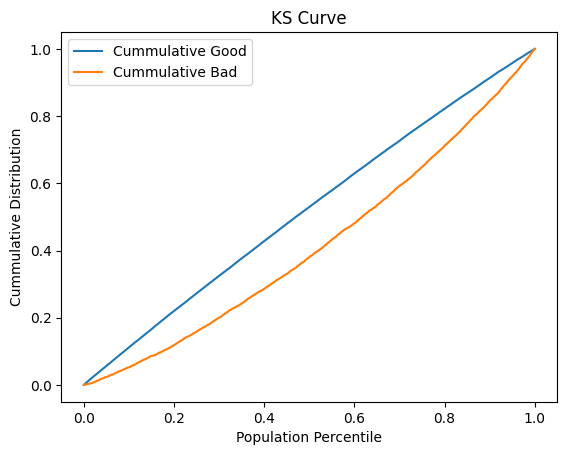




CONFUSION MATRICES
Matrix Format : [[TN FP][FN TP]]


Threshold : 0.5
[[28579     0]
 [ 7032     0]] - Recall : 0.00


Threshold : 0.45
[[28572     7]
 [ 7028     4]] - Recall : 0.00


Threshold : 0.4
[[28508    71]
 [ 6997    35]] - Recall : 0.00


Threshold : 0.35000000000000003
[[28187   392]
 [ 6830   202]] - Recall : 0.03


Threshold : 0.30000000000000004
[[26885  1694]
 [ 6251   781]] - Recall : 0.11


Threshold : 0.25000000000000006
[[23126  5453]
 [ 4884  2148]] - Recall : 0.31


Threshold : 0.20000000000000007
[[16046 12533]
 [ 2891  4141]] - Recall : 0.59


Threshold : 0.15000000000000008
[[ 7033 21546]
 [  988  6044]] - Recall : 0.86


Threshold : 0.10000000000000009
[[  679 27900]
 [   48  6984]] - Recall : 0.99


Threshold : 0.0500000000000001
[[    0 28579]
 [    0  7032]] - Recall : 1.00


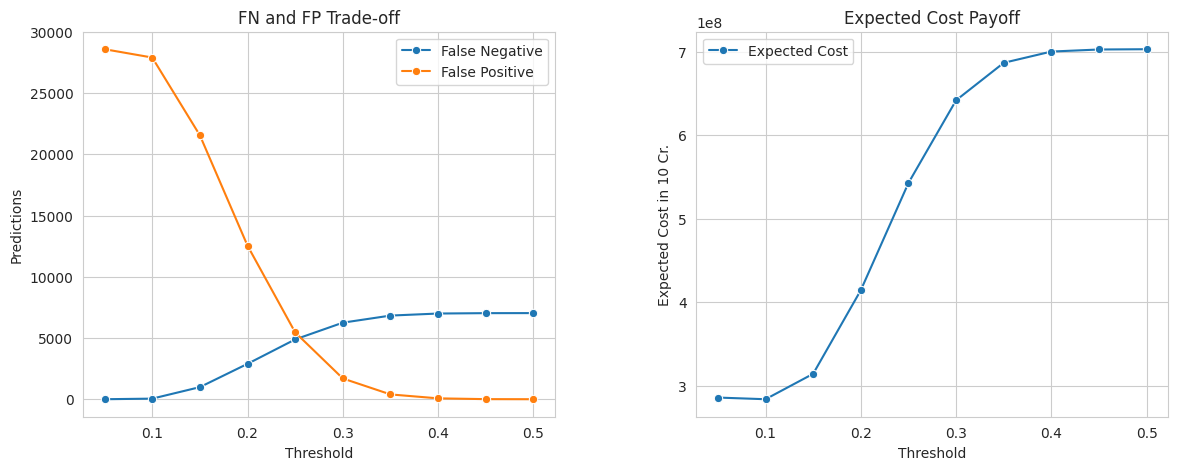

In [71]:
features = [
    'dti_woe',
    'annual_inc_woe',
    'revol_util_woe',
    'delinq_2yrs_woe',
    'inq_last_6mths_woe',
    'open_acc_woe',
    'pub_rec_woe'
]

model, coef_df = create_model(df_woe, features, 'default_flag')

### Creating new model with grade variable included.

In [72]:
# Creating new model with grade variable included "WOE Binning"

woe_cols = ['dti_bin', 'annual_inc_bin', 'revol_util_bin', 'delinq_2yrs_bin', 'inq_last_6mths_bin', 'open_acc_bin', 'pub_rec_bin', 'grade_bin']
iv_scores = []
temp = df.copy()
# print(temp.head())
temp.rename(columns={'grade':'grade_bin'}, inplace=True)
for col in woe_cols:
  temp, iv = add_woe(temp, col)
  iv_scores.append(iv)



In [73]:
iv_scores_df = pd.DataFrame({"Columns" : woe_cols, "IV Scores" : iv_scores})
iv_scores_df

,Columns,IV Scores
0,dti_bin,0.0752
1,annual_inc_bin,0.0271
2,revol_util_bin,0.0245
3,delinq_2yrs_bin,0.0025
4,inq_last_6mths_bin,0.0244
5,open_acc_bin,0.0053
6,pub_rec_bin,0.0070
7,grade_bin,0.4645


In [74]:
pd.DataFrame({"grade_bin " :temp[['grade_bin', 'grade_woe']].sort_values(by='grade_bin').reset_index()['grade_bin'].unique(), "grade_woe" : temp[['grade_bin', 'grade_woe']].sort_values(by='grade_bin').reset_index()['grade_woe'].unique()})

,grade_bin,grade_woe
0,A,1.3555
1,B,0.4841
2,C,-0.1382
3,D,-0.5661
4,E,-0.9267
5,F,-1.1375
6,G,-1.5379


COEFFICIENT VALUES
              Feature  Coefficient
0             dti_woe      -0.5076
1      annual_inc_woe      -0.6063
2      revol_util_woe      -0.0337
3     delinq_2yrs_woe      -0.4464
4  inq_last_6mths_woe      -0.1554
5        open_acc_woe      -0.8044
6         pub_rec_woe      -0.5987
7           grade_woe      -0.9471



MODEL ACCURACY
Accuracy Score :  0.8024206003762883



ROC-AUC SCORE
AUC :  0.6902617247697848



Kolmogorov-Smirnov Statistic (KS)
KS Value :  0.27854287484692547
Occured At :  y_actual   0.0000
y_prob     0.2033
good       1.0000
bad        0.0000
cum_good   0.6012
cum_bad    0.3227
cum_diff   0.2785
Name: 1719000, dtype: float64




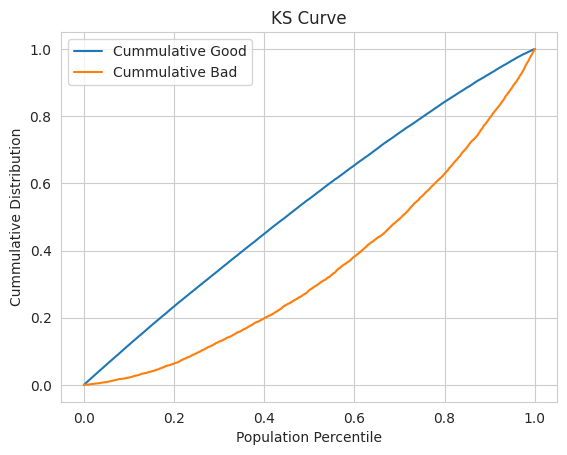




CONFUSION MATRICES
Matrix Format : [[TN FP][FN TP]]


Threshold : 0.5
[[28443   136]
 [ 6900   132]] - Recall : 0.02


Threshold : 0.45
[[28132   447]
 [ 6586   446]] - Recall : 0.06


Threshold : 0.4
[[27448  1131]
 [ 6131   901]] - Recall : 0.13


Threshold : 0.35000000000000003
[[26088  2491]
 [ 5365  1667]] - Recall : 0.24


Threshold : 0.30000000000000004
[[24292  4287]
 [ 4522  2510]] - Recall : 0.36


Threshold : 0.25000000000000006
[[21031  7548]
 [ 3350  3682]] - Recall : 0.52


Threshold : 0.20000000000000007
[[16923 11656]
 [ 2213  4819]] - Recall : 0.69


Threshold : 0.15000000000000008
[[12323 16256]
 [ 1316  5716]] - Recall : 0.81


Threshold : 0.10000000000000009
[[ 6144 22435]
 [  399  6633]] - Recall : 0.94


Threshold : 0.0500000000000001
[[ 1170 27409]
 [   37  6995]] - Recall : 0.99


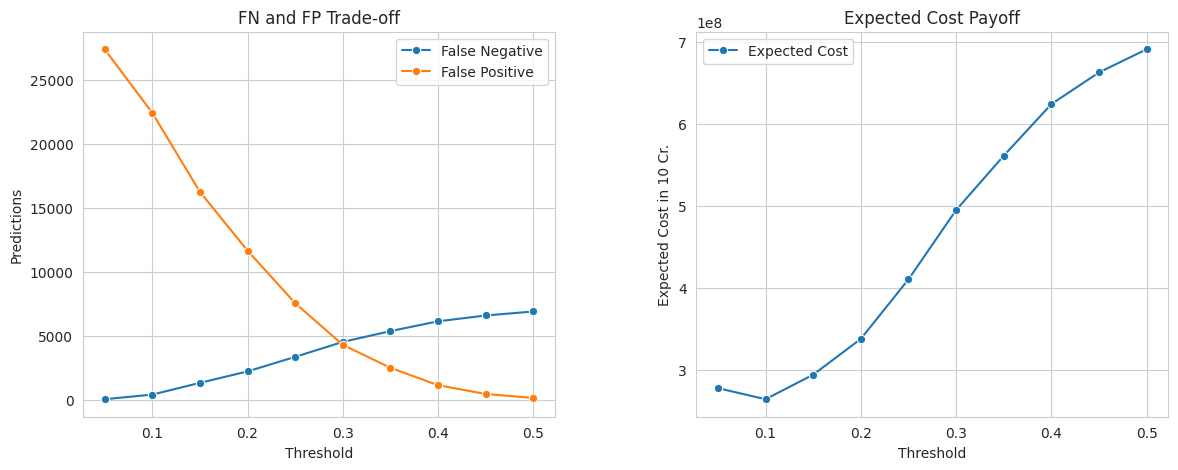

In [75]:
final_features = [
    'dti_woe',
    'annual_inc_woe',
    'revol_util_woe',
    'delinq_2yrs_woe',
    'inq_last_6mths_woe',
    'open_acc_woe',
    'pub_rec_woe',
    'grade_woe'
]
final_features.append('default_flag')
final_df_woe = temp[final_features]

final_features.remove('default_flag')
model, coef_df = create_model(final_df_woe, final_features, 'default_flag')

In this section, we created, evaluated and improved the model based on the metrics like KS, ROC-AUC, FN and FP Trade-off, Expected Cost Payoff and got the following results.


For now, we a our best logistic regression model based on

* woe_cols = ['dti_woe', 'annual_inc_woe', 'revol_util_woe', 'delinq_2yrs_woe', 'inq_last_6mths_woe', 'open_acc_woe', 'pub_rec_woe', 'grade_woe']

with following results:


* KS Statistic : 0.27854287484692547
* ROC-AUC Score : 0.6902617247697848
* Recall : 0.69
* Balance point Probability threshold : 0.2

By this, our Step 9 and Step 10 have been concluded.


##11) Scorecard Development

In this section, we'll proceed with score calculation with the following steps:
1. Convert PD → odds
2. Define Base Score, Base Odds, PDO
3. Calculate Factor
4. Calculate Offset
5. Convert model output → credit score
6. Assign points to each WOE bin
7. Calculate borrower scores

<br>

Important terms to know before proceeding further :


* Odds : The ratio of good borrowers to bad borrowers at a given risk level.
* Base Score : The reference score chosen as the starting point of the scoring system.
* Base Odds : The good-to-bad borrower ratio corresponding to the base score.
* PDO (Points to Double the Odds) : The number of score points required to double the borrower’s odds of being good.
* Factor : A scaling constant that converts model risk values into score points.
* Offset : A constant used to shift the score scale so the base score matches the base odds.
* Scorecard Scaling : The process of converting logistic regression output into a credit score.



In [76]:
# Base Variables
base_score = 600 # Reference Score of Average Risk Borrower
base_odds = 50 # Good : Bad -> 50 : 1 | Risk Level at Base Score
pdo = 20 # Points needed to double odds (Score Sensitivity)

In [77]:
# Calculate Factor and Offset

factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)
base_points = offset + factor * model.intercept_

In [78]:
temp.head()

,loan_amnt,grade_bin,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,...,open_acc_bin,pub_rec_bin,dti_woe,annual_inc_woe,revol_util_woe,delinq_2yrs_woe,inq_last_6mths_woe,open_acc_woe,pub_rec_woe,grade_woe
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,...,11-15,1,0.3579,-0.2172,0.0390,0.0219,-0.0812,-0.0267,-0.1737,-0.1382
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,...,16-20,0,0.0456,0.1011,0.3016,0.0219,0.1271,-0.0694,0.0389,1.3555
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,...,11-15,0,0.3579,-0.0945,0.3016,-0.0545,-0.0812,-0.0267,0.0389,0.4841
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,...,11-15,0,0.0456,0.1011,-0.0400,-0.0545,0.1271,-0.0267,0.0389,0.4841
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,...,6-10,0,0.0456,-0.2172,-0.1474,-0.0545,0.1271,0.0474,0.0389,0.4841


In [79]:
final_working_df = temp.copy()

In [80]:

variable_score_df = {}

cols = final_working_df.columns


for col in cols:
  if 'bin' in col:
    col_name = col.replace("_bin", "")
    col_woe = col.replace('bin', 'woe')
    variable_score_df[col_name] = final_working_df[[col, col_woe]].groupby(col, observed=True)[col_woe].first().reset_index().sort_values(col_woe, ascending=False)

    col_model_coef = float(coef_df[coef_df['Feature']==col_woe]['Coefficient'].iloc[0])

    variable_score_df[col_name]['points'] = -factor * variable_score_df[col_name][col_woe].astype(float) * col_model_coef

    variable_score_df[col_name].rename(columns={col : "bin", col_woe : "woe"}, inplace=True)
    variable_score_df[col_name]['variable'] = col_name

    variable_score_df[col_name] = variable_score_df[col_name][['variable', 'bin', 'woe', 'points']]





variable_score_df = pd.concat(variable_score_df.values(), ignore_index=True)


variable_score_df = variable_score_df.sort_values(['variable', 'woe'], ascending=False).reset_index(drop=True)

variable_score_df.rename(columns={'variable':'Variable', 'bin': 'Bin', 'woe': 'WOE', 'points': 'Points'}, inplace=True)

variable_score_df


,Variable,Bin,WOE,Points
0,revol_util,"(-0.001, 29.1]",0.3016,0.2932
1,revol_util,"(29.1, 45.1]",0.0390,0.0379
2,revol_util,"(45.1, 59.3]",-0.0400,-0.0388
3,revol_util,"(59.3, 75.1]",-0.1159,-0.1127
4,revol_util,"(75.1, 100.0]",-0.1474,-0.1432
5,pub_rec,0,0.0389,0.6716
6,pub_rec,1,-0.1737,-3.0011
7,pub_rec,2+,-0.2037,-3.5192
8,open_acc,1-5,0.1308,3.0369
9,open_acc,6-10,0.0474,1.0992


In [81]:
final_working_df.head()


,loan_amnt,grade_bin,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,...,open_acc_bin,pub_rec_bin,dti_woe,annual_inc_woe,revol_util_woe,delinq_2yrs_woe,inq_last_6mths_woe,open_acc_woe,pub_rec_woe,grade_woe
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,...,11-15,1,0.3579,-0.2172,0.0390,0.0219,-0.0812,-0.0267,-0.1737,-0.1382
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,...,16-20,0,0.0456,0.1011,0.3016,0.0219,0.1271,-0.0694,0.0389,1.3555
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,...,11-15,0,0.3579,-0.0945,0.3016,-0.0545,-0.0812,-0.0267,0.0389,0.4841
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,...,11-15,0,0.0456,0.1011,-0.0400,-0.0545,0.1271,-0.0267,0.0389,0.4841
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,...,6-10,0,0.0456,-0.2172,-0.1474,-0.0545,0.1271,0.0474,0.0389,0.4841


In [82]:
# Assign Points to each borrower
# For each borrower, match variables -> match bins -> assign points -> sum points

cols_bin = [col for col in final_working_df.columns if '_bin' in col]
cols = [col.replace("_bin", "") for col in cols_bin]

for col in cols:
  temp = variable_score_df[variable_score_df['Variable']==col]
  mapping = dict(zip(temp['Bin'], temp['Points']))
  final_working_df[f'{col}_points'] = final_working_df[f'{col}_bin'].map(mapping)


point_cols = [
'dti_points',
'annual_inc_points',
'revol_util_points',
'delinq_2yrs_points',
'inq_last_6mths_points',
'open_acc_points',
'pub_rec_points',
'grade_points'
]

final_working_df['variable_points_sum'] = final_working_df[point_cols].sum(axis=1)

final_working_df['credit_score'] = base_score + final_working_df['variable_points_sum']

In [83]:
final_working_df.describe()

,loan_amnt,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,delinq_2yrs_woe,...,open_acc_woe,pub_rec_woe,grade_woe,grade_points,delinq_2yrs_points,inq_last_6mths_points,open_acc_points,pub_rec_points,variable_points_sum,credit_score
count,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,...,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000,118703.0000
mean,14401.4340,74488.3086,18.1620,0.3181,0.6595,11.5983,0.2156,51.8831,0.2002,0.0007,...,0.0016,0.0020,0.1491,4.0752,0.0092,0.0315,0.0367,0.0346,4.6651,604.6651
std,8712.0259,42015.9277,8.4427,0.8698,0.9398,5.4509,0.6220,24.5273,0.4002,0.0487,...,0.0726,0.0817,0.7255,19.8246,0.6274,0.6871,1.6862,1.4120,22.0200,22.0200
min,500.0000,1000.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,-0.2003,...,-0.1719,-0.2037,-1.5379,-42.0239,-2.5801,-1.9635,-3.9902,-3.5192,-59.5845,540.4155
25%,7925.0000,46000.0000,11.7900,0.0000,0.0000,8.0000,0.0000,33.5000,0.0000,0.0219,...,-0.0267,0.0389,-0.5661,-15.4684,0.2817,-0.3640,-0.6208,0.6716,-11.2682,588.7318
50%,12000.0000,65000.0000,17.6800,0.0000,0.0000,11.0000,0.0000,52.3000,0.0000,0.0219,...,-0.0267,0.0389,-0.1382,-3.7759,0.2817,0.5702,-0.6208,0.6716,2.6632,602.6632
75%,20000.0000,90000.0000,24.1000,0.0000,1.0000,14.0000,0.0000,70.9000,0.0000,0.0219,...,0.0474,0.0389,0.4841,13.2294,0.2817,0.5702,1.0992,0.6716,18.4951,618.4951
max,40000.0000,250000.0000,38.4000,29.0000,7.0000,84.0000,61.0000,100.0000,1.0000,0.0219,...,0.1308,0.0389,1.3555,37.0421,0.2817,0.5702,3.0369,0.6716,51.9551,651.9551


In [84]:
final_working_df.head(5)

,loan_amnt,grade_bin,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,...,grade_points,dti_points,annual_inc_points,revol_util_points,delinq_2yrs_points,inq_last_6mths_points,open_acc_points,pub_rec_points,variable_points_sum,credit_score
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,...,-3.7759,5.2421,-3.8000,0.0379,0.2817,-0.3640,-0.6208,-3.0011,-6.0001,593.9999
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,...,37.0421,0.6674,1.7683,0.2932,0.2817,0.5702,-1.6115,0.6716,39.6831,639.6831
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,...,13.2294,5.2421,-1.6538,0.2932,-0.7015,-0.3640,-0.6208,0.6716,16.0962,616.0962
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,...,13.2294,0.6674,1.7683,-0.0388,-0.7015,0.5702,-0.6208,0.6716,15.5458,615.5458
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,...,13.2294,0.6674,-3.8000,-0.1432,-0.7015,0.5702,1.0992,0.6716,11.5931,611.5931


In [85]:
borrower_score_df = final_working_df[['loan_amnt', 'grade_bin', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'default_flag', 'credit_score']].copy()

##12) Risk Segmentation

In this section we create risk bands by binning the borrowers based on their credit scores.

In [86]:
# Creating Risk Bands

borrower_score_df['risk_band'] = pd.cut(borrower_score_df['credit_score'], bins=[0, 580, 620, 680, 1000], labels=['High Risk', 'Moderate Risk', 'Low Risk', 'Very Low Risk'])

borrower_score_df

,loan_amnt,grade_bin,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,default_flag,credit_score,risk_band
1273506,9600.0000,C,21900.0000,10.0300,0.0000,1.0000,13.0000,1.0000,38.9000,0,593.9999,Moderate Risk
324024,4000.0000,A,83000.0000,19.5300,0.0000,0.0000,16.0000,0.0000,17.2000,0,639.6831,Low Risk
2066630,6025.0000,B,52000.0000,9.1600,1.0000,1.0000,11.0000,0.0000,12.8000,0,616.0962,Moderate Risk
1975547,20000.0000,B,100000.0000,16.4300,1.0000,0.0000,15.0000,0.0000,56.3000,0,615.5458,Moderate Risk
302723,1000.0000,B,23000.0000,16.3400,1.0000,0.0000,6.0000,0.0000,77.1000,0,611.5931,Moderate Risk
...,...,...,...,...,...,...,...,...,...,...,...,...
2182982,5000.0000,A,42000.0000,22.7100,0.0000,0.0000,7.0000,0.0000,10.4000,0,633.8586,Low Risk
244166,35000.0000,C,250000.0000,5.6700,0.0000,1.0000,11.0000,0.0000,50.1000,1,606.2132,Moderate Risk
1194644,16000.0000,C,102000.0000,10.2200,0.0000,1.0000,10.0000,0.0000,46.1000,0,607.9332,Moderate Risk
201566,3700.0000,B,40000.0000,17.2500,0.0000,0.0000,9.0000,0.0000,29.7000,0,612.7574,Moderate Risk


In [94]:
# Getting Bad Rate by risk_band

risk_table = borrower_score_df.groupby('risk_band', observed=True)['default_flag'].agg(['mean', 'count'])
risk_table['distribution'] = (risk_table['count']/risk_table['count'].sum()) * 100

                mean  count  distribution
risk_band                                
High Risk     0.3988  16160       13.6138
Moderate Risk 0.2035  75971       64.0009
Low Risk      0.0700  26572       22.3853


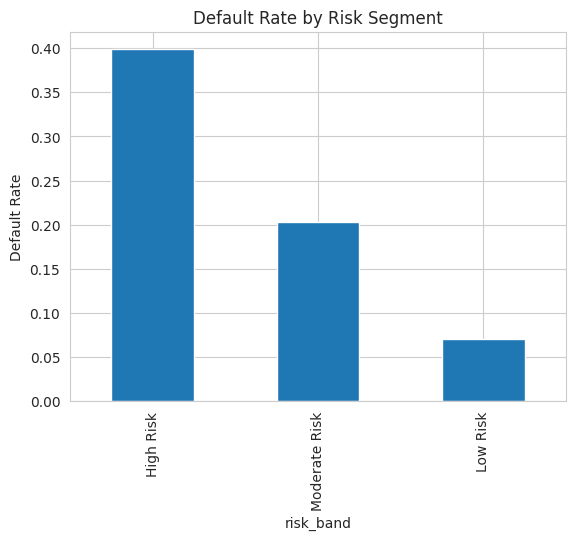

In [95]:
print(risk_table)

risk_table['mean'].plot(kind='bar')

plt.ylabel('Default Rate')
plt.title("Default Rate by Risk Segment")
plt.show()

This section has shown us the following bad_rate:
* High Risk : ~40% : means out of 100 borrowers 40 are more likely to be defaulter.
* Medium Risk : ~20% : means out of 100 borrowers 20 are more likely to be defaulter.
* Low Risk : ~7% : means out of 100 borrowers 7 are more likely to be defaulter.



##13) Credit Policy Recommendation

Based on the developed credit scorecard and borrower risk segmentation, the following credit approval strategy can be proposed.

1. **Low Risk Segment**

    * Default Rate: ~7%
    * Borrower Share: ~22%


  * Recommendation

    * Approve loans with minimal restrictions.
    * Offer competitive interest rates.
    * Suitable for higher loan exposure

  * Reason: Low historical default probability indicates strong repayment capacity.


2. **Moderate Risk Segment**
    * Default Rate: ~20%
    * Borrower Share: ~64%

  * Recommendation
    * Approve with additional checks.
    * Apply stricter underwriting rules.
    * Possible actions:
       * Lower loan limits
       * Higher interest rates
       * Require additional documentation.

  * Reason: Moderate default risk requires careful credit monitoring.


3. **High Risk Segment**
    * Default Rate: ~40%
    * Borrower Share: ~14%

  * Recommendation
    * Reject most applications.
    * Only approve under exceptional conditions:
       * Strong collateral
       * Co-applicant / guarantor

  * Reason: Very high probability of default leads to significant credit loss risk.



###Business Impact
Implementing this scorecard-based decision system can provide the following benefits:
* Improved credit approval accuracy
* Reduced portfolio default rates
* Better risk-based pricing strategies
* Enhanced portfolio risk monitoring